# Модель для предсказания возрастной категории пользователей

   Выполнила: Тулянцева Альбина
   
   Дата: 21.04.2026
   
   **Описание проекта:** Заказчик проекта — крупная IT-компания «Йети», которая управляет группой популярных интернет-сервисов. Каждый день через них проходят миллионы пользователей. Значительную часть дохода компания получает от контекстной рекламы, то есть от объявлений на страницах своих сайтов.
   
Алгоритмы рекламной сети «Йети» (РСЙ) используют демографический таргетинг, включая возрастной. Они собирают данные через технологию, анализирующую поведение пользователей без прямого доступа к их паспортным данным.

Если реклама гаджетов будет показана семейным людям с ребёнком, а спокойный семейный ролик — юным геймерам, то маркетинговая кампания обоих продуктов провалится. Рекламный бюджет растает на глазах, конверсия РСЙ упадёт, а пользователи будут недовольны ненужными объявлениями.

Чтобы избежать такой ситуации, нужна модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст. Это позволит показывать товар тем, кому он действительно нужен.

   **Цель:** создать модель, которая будет автоматически определять возрастную категорию пользователей.
   
   **Задачи:**
   1. Подготовка среды и библиотек
   2. Исследовательский анализ данных
   3. Предобработка данных
   4. Обучение и оценка базовой модели
   5. Создание и отбор признаков
   6. Подбор гиперпараметров моделей
   7. Подготовка артефактов модели для внедрения
   8. Выводы о результатах работы
   
   **Данные:**
   
   **Таблица users:**
   
   user_id — уникальный идентификатор пользователя.
   
age_category — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. 

Содержит следующие категории:
**0**: младше 18;
**1**: 18-25 лет;
**2**: 26-40 лет;
**3**: 41-55 лет;
**4**: 56+ лет.

   **Таблица visits:**
   
   date — дата посещения сайта.
   
   daytime — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
   
   session_id — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
   
   user_id — уникальный идентификатор пользователя.
   
   website_category — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.
   
   **Таблица ads_activity:**
   
   user_id — уникальный идентификатор пользователя.
   
   ads_activity — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.
   
   **Таблица surf_depth:**
   
   user_id — уникальный идентификатор пользователя.
   
   surf_depth — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.
   
   **Таблица primary_device:**
   
   user_id — уникальный идентификатор пользователя.
   
   primary_device — информация о типе основного устройства пользователя для выхода в Интернет.
   
   **Таблица cloud_usage:**
   
   user_id — уникальный идентификатор пользователя;
   
   cloud_usage — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.
   
   **Постановка задачи машинного обучения:** данная задача представляет собой многоклассовую классификацию. Так как некоторые признаки могут быть не связаны линейно, помимо Логистической регрессии будут использованы модели опорных векторов с разными ядрами. Для подбора лучших гиперпараметров разных моделей будет использоваться GridSearchCV.
   
   Целевой переменной является **age_category** - возрастная категория пользователя.
   
   В качестве основной метрики будет использована F1-меру. Вспомогательные метрики качества: precision и recall. Модель нужно оценить одинаково по всем классам, даже если один из них встречается редко, поэтому будем использовать макро-усреднение.
   
   Значение F1-меры лучшей модели должно быть не меньше 0.75 и на кросс-валидации по обучающей выборке, и на тестовой выборке. В этом случае модель можно рекомендовать к внедрению.

## Подготовка среды и библиотек

In [1]:
%%writefile requirements.txt
pandas==1.5.3
matplotlib==3.7.2
seaborn==0.12.2
numpy ==1.22.4
scikit-learn==1.3.0
scipy==1.10.1
phik==0.12.3
joblib==1.3.2

Writing requirements.txt


In [2]:
#Вызовем этот файл
!pip install -r requirements.txt -q

In [3]:
#Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Импорт модулей библиотеки scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import VarianceThreshold

#Импорт phik
from phik import phik_matrix

#Импорт joblib
import joblib
from datetime import datetime

#Фиксируем random_state
RANDOM_STATE = 42

In [4]:
# Загрузка всех датафреймов
users = pd.read_csv('/datasets/ds_s13_users.csv')
visits = pd.read_csv('/datasets/ds_s13_visits.csv')
ads_activity = pd.read_csv('/datasets/ads_activity.csv')
surf_depth = pd.read_csv('/datasets/surf_depth.csv')
primary_device = pd.read_csv('/datasets/primary_device.csv')
cloud_usage = pd.read_csv('/datasets/cloud_usage.csv')

In [5]:
#Изучим основную информацию о данных и проверим их на выбросы
users.info()

print(f'Количество дубликатов:{users.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB
Количество дубликатов:87


In [6]:
visits.info()

print(f'Количество дубликатов:{visits.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB
Количество дубликатов:15750


In [7]:
ads_activity.info()

print(f'Количество дубликатов:{ads_activity.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB
Количество дубликатов:233


In [8]:
surf_depth.info()

print(f'Количество дубликатов:{surf_depth.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB
Количество дубликатов:0


In [9]:
primary_device.info()

print(f'Количество дубликатов:{primary_device.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB
Количество дубликатов:0


In [10]:
cloud_usage.info()

print(f'Количество дубликатов:{cloud_usage.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB
Количество дубликатов:0


В данных наблюдаются дубликаты, поэтому удалим их в датасетах, чтобы избежать перезапись строк.

In [11]:
#Удаляем признаки
users = users.drop_duplicates()
visits = visits.drop_duplicates(subset=['session_id'])
ads_activity = ads_activity.drop_duplicates()
surf_depth = surf_depth.drop_duplicates()
primary_device = primary_device.drop_duplicates()
cloud_usage = cloud_usage.drop_duplicates()

In [12]:
visits['date'] = pd.to_datetime(visits['date'])

# Получаем минимальную и максимальную дату
min_date = visits['date'].min()
max_date = visits['date'].max()

print(f"Период данных: с {min_date.strftime('%Y-%m-%d')} по {max_date.strftime('%Y-%m-%d')}")

Период данных: с 2025-11-01 по 2025-11-14


Данные предоставлены за период 14 дней.

In [13]:
print("Размер users:", users.shape)
print("Размер visits:", visits.shape)
print("Размер ads_activity:", ads_activity.shape)
print("Размер surf_depth:", surf_depth.shape)
print("Размер primary_device:", primary_device.shape)
print("Размер cloud_usage:", cloud_usage.shape)

Размер users: (5826, 2)
Размер visits: (1049995, 5)
Размер ads_activity: (5593, 2)
Размер surf_depth: (5715, 2)
Размер primary_device: (5669, 2)
Размер cloud_usage: (5680, 2)


После загрузки датасетов мы видим, что в датасете visits намного больше строк, чем в остальных. Это связано с тем, что за одним user_id закреплены многочисленные посещения сайтов. Если соединять датасеты в изнчальном виде, то это может привести к переобучению модели, так как один user_id может попасть в обучающую и тестовую выборки. Так модель "подглядит" ответы. Чтобы этого избежать, перед присоединением агрегируем признаки в датасете visits, чтобы у одного user_id остались только количество сессий(session_id), количество уникальных дней с активностью, среднее количество сессий в день, самое частое время посещения сайта, доля активности по времени суток и самая частая категория посещаемых сайтов, доля активности по категориям. Также можно добавить количество уникальных категорий сайтов, чтобы модель видела, насколько разнятся предпочтения пользователя.

In [14]:
def build_feature_matrix(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    df = users.copy()
    
    #Присоединяем остальные таблицы
    df = df.merge(ads_activity, on='user_id', how='left')
    df = df.merge(surf_depth, on='user_id', how='left')
    df = df.merge(primary_device, on='user_id', how='left')
    df = df.merge(cloud_usage, on='user_id', how='left')
    
    #Общее количество сессий
    session_count = visits.groupby('user_id')['session_id'].count().rename('session_count')
    
    #Количество уникальных дней с активностью
    if 'date' in visits.columns:
        unique_days = visits.groupby('user_id')['date'].nunique().rename('active_days_count')
    else:
        #Если нет даты, считаем что каждый пользователь активен 1 день
        unique_days = pd.Series(1, index=session_count.index, name='active_days_count')
    
    #Среднее количество сессий в день
    avg_sessions_per_day = (session_count / unique_days).fillna(0).rename('avg_sessions_per_day')
    
    #Количество уникальных категорий сайтов
    website_category_count = visits.groupby('user_id')['website_category'].nunique().rename('website_category_count')
    
    #Наиболее активное время суток
    common_daytime = visits.groupby('user_id')['daytime'].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan
    ).rename('common_daytime')
    
    #Доля активности по времени суток
    daytime_ratio = pd.crosstab(
        visits['user_id'], 
        visits['daytime'], 
        normalize='index'
    ).add_prefix('daytime_ratio_')
    
    #Самая часто посещаемая категория сайта
    common_website_category = visits.groupby('user_id')['website_category'].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan
    ).rename('common_website_category')
    
    #Доля активности по категориям сайтов
    category_ratio = pd.crosstab(
        visits['user_id'], 
        visits['website_category'], 
        normalize='index'
    ).add_prefix('category_ratio_')
    
    #Объединяем все признаки
    visits_agg = pd.concat([
        session_count,
        unique_days,
        avg_sessions_per_day,
        website_category_count,
        common_daytime,
        daytime_ratio,
        common_website_category,
        category_ratio
    ], axis=1)
    
    #Присоединяем к основному df
    df = df.merge(visits_agg, on='user_id', how='left')
    
    return df

In [15]:
#Применяем функцию
df = build_feature_matrix(users, visits, ads_activity, surf_depth, primary_device, cloud_usage)

In [16]:
#Смотрим первые 5 строк
df.head()

,user_id,age_category,ads_activity,surf_depth,primary_device,cloud_usage,session_count,active_days_count,avg_sessions_per_day,website_category_count,...,category_ratio_Category 11,category_ratio_Category 12,category_ratio_Category 13,category_ratio_Category 14,category_ratio_Category 15,category_ratio_Category 16,category_ratio_Category 17,category_ratio_Category 18,category_ratio_Category 19,category_ratio_Category 20
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,NaN,глубоко,смартфон,False,187,14,13.357143,19,...,0.074866,0.016043,0.032086,0.037433,0.053476,0.042781,0.058824,0.069519,0.074866,0.042781
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно,средне,смартфон,False,141,14,10.071429,19,...,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461
2,678b-614cd47d854b9d591db2-000b2e50,0,умеренно,средне,смартфон,False,100,14,7.142857,17,...,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,редко,поверхностно,смартфон,True,248,14,17.714286,19,...,0.064516,0.016129,0.076613,0.020161,0.024194,0.028226,0.064516,0.133065,0.036290,0.012097
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,очень редко,поверхностно,смартфон,True,119,14,8.500000,19,...,0.042017,0.126050,0.000000,0.084034,0.025210,0.025210,0.050420,0.033613,0.025210,0.058824


In [17]:
#Смотрим последние 5 строк
df.tail()

,user_id,age_category,ads_activity,surf_depth,primary_device,cloud_usage,session_count,active_days_count,avg_sessions_per_day,website_category_count,...,category_ratio_Category 11,category_ratio_Category 12,category_ratio_Category 13,category_ratio_Category 14,category_ratio_Category 15,category_ratio_Category 16,category_ratio_Category 17,category_ratio_Category 18,category_ratio_Category 19,category_ratio_Category 20
5821,f4bd-a23c0f510067ac3836b6-052bd910,0,умеренно,средне,планшет,True,213,14,15.214286,19,...,0.037559,0.042254,0.000000,0.070423,0.028169,0.009390,0.070423,0.075117,0.084507,0.046948
5822,eda0-e3e82537c708854dd5f2-ec0540bf,3,редко,глубоко,смартфон,False,160,14,11.428571,19,...,0.025000,0.025000,0.075000,0.031250,0.087500,0.087500,0.012500,0.062500,0.075000,0.031250
5823,e0d8-1b36a6b475ebfbf87c14-fa566d97,0,редко,поверхностно,планшет,True,253,14,18.071429,19,...,0.043478,0.035573,0.047431,0.007905,0.023715,0.007905,0.023715,0.055336,0.138340,0.047431
5824,ad58-7c3c5b76a1dd90ba850d-0307d559,3,очень редко,поверхностно,ноутбук,True,123,14,8.785714,19,...,0.024390,0.016260,0.089431,0.032520,0.048780,0.056911,0.032520,0.016260,0.089431,0.040650
5825,c892-72c57d41488d7956d880-3474e42b,2,умеренно,средне,смартфон,NaN,164,14,11.714286,18,...,0.012195,0.012195,0.073171,0.024390,0.067073,0.012195,0.018293,0.054878,0.109756,0.109756


Датасеты объединены и агрегированы успешно. Уже сейчас можно предварительно проанализировать данные и сказать, что в столбце primary_device часто встречается значение "смартфон", а в столбце active_days_count - значение 14.

In [18]:
#Смотрим общую информацию о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5826 entries, 0 to 5825
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5826 non-null   object 
 1   age_category                5826 non-null   int64  
 2   ads_activity                5593 non-null   object 
 3   surf_depth                  5715 non-null   object 
 4   primary_device              5669 non-null   object 
 5   cloud_usage                 5680 non-null   object 
 6   session_count               5826 non-null   int64  
 7   active_days_count           5826 non-null   int64  
 8   avg_sessions_per_day        5826 non-null   float64
 9   website_category_count      5826 non-null   int64  
 10  common_daytime              5826 non-null   object 
 11  daytime_ratio_вечер         5826 non-null   float64
 12  daytime_ratio_день          5826 non-null   float64
 13  daytime_ratio_ночь          5826 

In [19]:
#Размерность датасета
df.shape

(5826, 36)

Всего в датасете присутствует 5826 строк, а также 35 признаков и 1 целевая переменная. Все признаки принадлежат к правильному типу данных, кроме cloud_usage, который имеет значения True/False, но имеет тип object. Большинство признаков принадлежат к числовому типу. Явные пропуски присутствуют в столбцах ads_activity, surf_depth, primary_device, cloud_usage. Переведем cloud_usage в числовой признак после разделения на выборки.

In [20]:
#Смотрим информацию о числовых признаках
df.describe()

,age_category,session_count,active_days_count,avg_sessions_per_day,website_category_count,daytime_ratio_вечер,daytime_ratio_день,daytime_ratio_ночь,daytime_ratio_утро,category_ratio_Category 01,...,category_ratio_Category 11,category_ratio_Category 12,category_ratio_Category 13,category_ratio_Category 14,category_ratio_Category 15,category_ratio_Category 16,category_ratio_Category 17,category_ratio_Category 18,category_ratio_Category 19,category_ratio_Category 20
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,...,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,2.440439,180.225712,13.998627,12.874047,18.472880,0.358199,0.364961,0.078108,0.198733,0.049933,...,0.036852,0.047742,0.064447,0.043433,0.048679,0.043211,0.046991,0.048007,0.051999,0.047940
std,1.381287,75.186802,0.037034,5.369733,0.767831,0.048836,0.045206,0.024633,0.038134,0.031238,...,0.027020,0.030454,0.057089,0.029823,0.028532,0.028434,0.029080,0.031702,0.028733,0.029135
min,0.000000,100.000000,13.000000,7.142857,14.000000,0.214286,0.217822,0.000000,0.049505,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,124.000000,14.000000,8.857143,18.000000,0.324324,0.335058,0.060606,0.172575,0.026786,...,0.016048,0.024845,0.008130,0.020000,0.028846,0.021277,0.025641,0.024540,0.031059,0.026667
50%,3.000000,167.000000,14.000000,11.928571,19.000000,0.357542,0.365385,0.076142,0.196765,0.048630,...,0.033528,0.046403,0.056936,0.041237,0.047619,0.040381,0.045161,0.044329,0.050000,0.045595
75%,4.000000,213.000000,14.000000,15.214286,19.000000,0.391304,0.395664,0.093407,0.223863,0.070000,...,0.054217,0.068182,0.102795,0.062850,0.067227,0.060309,0.064852,0.067797,0.070000,0.066667
max,4.000000,839.000000,14.000000,59.928571,19.000000,0.530000,0.532710,0.198020,0.360000,0.182927,...,0.174603,0.178571,0.295918,0.190000,0.198020,0.160305,0.187970,0.195804,0.180000,0.179688


В столбце session_count данные распределены почти равномерно, так как медиана находится близко к среднему значению. В столбце website_category_count большинство значений равны 19, а в active_days_count - 14. В остальных столбцах не наблюдается каких-то аномальных значений.

**Общие выводы:** перед присоединением были удалены дубликаты в датасетах, а также агрегированы признаки в датасете visits, чтобы у одного user_id остались только количество сессий(session_id), количество уникальных дней с активностью, среднее количество сессий в день, самое частое время посещения сайта, доля активности по времени суток и самая частая категория посещаемых сайтов, доля активности по категориям. Также было добавлено количество уникальных категорий сайтов, чтобы модель видела, насколько разнятся предпочтения пользователя. Датасеты были объединены и агрегированы успешно. Уже сейчас можно предварительно проанализировать данные и сказать, что в столбце primary_device часто встречается значение "смартфон", а в столбце active_days_count - значение 14. Всего в датасете присутствует 5826 строк, а также 35 признаков и 1 целевая переменная. Все признаки принадлежат к правильному типу данных, кроме cloud_usage, который имеет значения True/False, но имеет тип object. Большинство признаков принадлежат к числовому типу. Явные пропуски присутствуют в столбцах ads_activity, surf_depth, primary_device, cloud_usage. cloud_usage был переведен в числовой признак. В столбце session_count данные распределены почти равномерно, так как медиана находится близко к среднему значению. В столбце website_category_count большинство значений равны 19, а в active_days_count - 14. В остальных столбцах не наблюдается каких-то аномальных значений.

## Исследовательский анализ данных

**2.1 Анализ целевой переменной**

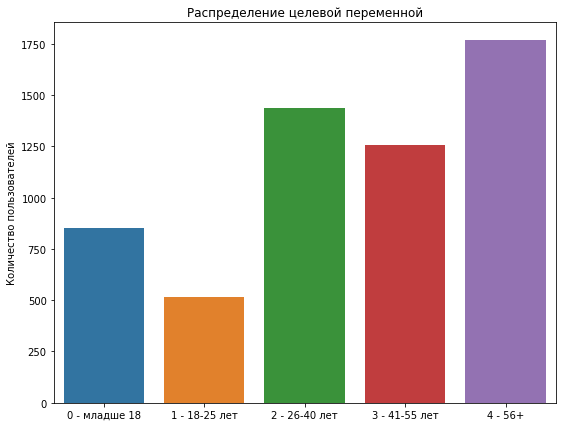

In [21]:
#Построим countplot для визуализации распределения целевой переменной
plt.figure(figsize=(9, 7))
ax = sns.countplot(data=df, x='age_category')
plt.title('Распределение целевой переменной')
plt.xlabel('')
plt.ylabel('Количество пользователей')

ax.set_xticklabels(['0 - младше 18', '1 - 18-25 лет', '2 - 26-40 лет', '3 - 41-55 лет', '4 - 56+'])
plt.show()

In [22]:
# Проценты от общего числа
print(df['age_category'].value_counts(normalize=True).sort_index() * 100)

0    14.641263
1     8.822520
2    24.699622
3    21.524202
4    30.312393
Name: age_category, dtype: float64


На графике видно, что данные в целевой переменной распределены неравномерно. Больше всего пользователей находится в категории 56+ лет, а меньше всего - 18-25 лет. Так как данные несбалансированные, при выборе метрик будем ориентироваться на макро-усреднение.

**2.2 Проверка дубликатов**

In [23]:
#Проверим, есть ли в данных явные дубликаты
len_duplicates = df.duplicated().sum()

print(f'Количество явных дубликатов: {len_duplicates}')

#Считаем дубликаты в связке user_id и age_category
len_duplicates_id_age = df.duplicated(subset=['user_id', 'age_category']).sum()

print(f'Количество дубликатов в связке user_id и age_category: {len_duplicates_id_age}')

Количество явных дубликатов: 0
Количество дубликатов в связке user_id и age_category: 0


После анализа явные дубликаты не были выявлены

**2.3 Анализ признаков**

Для успешной работы модели нужно избавиться от признаков, которые нужны лишь для записи данных и не несут пользы для модели. В данном датасете этот признак всего один - user_id. Удалим его.

In [24]:
#Удаляем user_id

df = df.drop(columns=['user_id'])

**2.4 Анализ пропущенных значений**

In [25]:
#Посмотрим на количество пропусков в каждом столбце
print(df.isna().sum())

age_category                    0
ads_activity                  233
surf_depth                    111
primary_device                157
cloud_usage                   146
session_count                   0
active_days_count               0
avg_sessions_per_day            0
website_category_count          0
common_daytime                  0
daytime_ratio_вечер             0
daytime_ratio_день              0
daytime_ratio_ночь              0
daytime_ratio_утро              0
common_website_category         0
category_ratio_Category 01      0
category_ratio_Category 02      0
category_ratio_Category 03      0
category_ratio_Category 04      0
category_ratio_Category 05      0
category_ratio_Category 06      0
category_ratio_Category 07      0
category_ratio_Category 08      0
category_ratio_Category 09      0
category_ratio_Category 10      0
category_ratio_Category 11      0
category_ratio_Category 12      0
category_ratio_Category 13      0
category_ratio_Category 14      0
category_ratio

In [26]:
#Изучим доли пропусков
for column in ['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']:
    missing_ratio = round((df[column].isna().sum()/len(df))*100, 2)
    print(f'Доля пропущенных значений в столбце {column}: {missing_ratio}%')

Доля пропущенных значений в столбце ads_activity: 4.0%
Доля пропущенных значений в столбце surf_depth: 1.91%
Доля пропущенных значений в столбце primary_device: 2.69%
Доля пропущенных значений в столбце cloud_usage: 2.51%


Пропуски наблюдаются в столбцах ads_activity, surf_depth, primary_device, cloud_usage. Так как пропуски составляют меньше 5%, то категориальные столбцы заменим наиболее частым значением, а бинарный признак cloud_usage заменим модой.

**2.5 Анализ категориальных признаков**

In [27]:
#Проверим уникальные значения в категориальных признаках
for column in ['ads_activity', 'surf_depth', 'primary_device', 
               'common_daytime', 'common_website_category']:
    print(f'\nУникальные значения в столбце {column}: {df[column].unique()}')


Уникальные значения в столбце ads_activity: [nan 'умеренно' 'редко' 'очень редко' 'очень часто' 'часто']

Уникальные значения в столбце surf_depth: ['глубоко' 'средне' 'поверхностно' nan]

Уникальные значения в столбце primary_device: ['смартфон' 'ноутбук' 'ПК' 'планшет' nan]

Уникальные значения в столбце common_daytime: ['день' 'вечер' 'утро']

Уникальные значения в столбце common_website_category: ['Category 05' 'Category 07' 'Category 12' 'Category 18' 'Category 14'
 'Category 08' 'Category 17' 'Category 13' 'Category 06' 'Category 16'
 'Category 04' 'Category 19' 'Category 03' 'Category 15' 'Category 01'
 'Category 10' 'Category 02' 'Category 09' 'Category 20' 'Category 11']


В категориальных признаках не наблюдается неявных дубликатов. Признаки ads_activity, surf_depth, primary_device, common_daytime, common_website_category имеют немного уникальных значений, поэтому их будем кодировать с помощью OneHotEncoder.

**2.6 Анализ выбросов распределений**

In [28]:
# Словарь обозначений
plot_labels = {
    'ads_activity': {
        'title': 'Распределение по частоте кликов',
        'xlabel': 'Активность',
        'ylabel': 'Количество пользователей'
    },
    'surf_depth': {
        'title': 'Распределение по глубине сессии пользователя',
        'xlabel': 'Глубина перехода',
        'ylabel': 'Количество пользователей'
    },
    'primary_device': {
        'title': 'Распределение по типу основного устройства',
        'xlabel': 'Тип устройства',
        'ylabel': 'Количество пользователей'
    },
    'cloud_usage': {
        'title': 'Распределение по использованию облачных ресурсов',
        'xlabel': 'Использование облака',
        'ylabel': 'Количество пользователей'
    },
    'session_count': {
        'title': 'Распределение по количеству уникальных сессий',
        'xlabel': 'Количество уникальных сессий',
        'ylabel': 'Количество пользователей'
    },
    'common_daytime': {
        'title': 'Распределение по наиболее частому времени посещения',
        'xlabel': 'Время дня',
        'ylabel': 'Количество пользователей'
    },
    'common_website_category': {
        'title': 'Распределение по наиболее частой категории сайта',
        'xlabel': 'Категория сайта',
        'ylabel': 'Количество пользователей'
    },
    'website_category_count': {
        'title': 'Распределение по количеству уникальных категорий сайтов',
        'xlabel': 'Количество категорий сайтов',
        'ylabel': 'Количество пользователей'
    },
    'active_days_count': {
        'title': 'Распределение по количеству уникальных дней с активностью',
        'xlabel': 'Количество активных дней',
        'ylabel': 'Количество пользователей'
    },
    'avg_sessions_per_day': {
        'title': 'Распределение по среднему количеству сессий в день',
        'xlabel': 'Среднее количество сессий в день',
        'ylabel': 'Количество пользователей'
    },
    'daytime_ratio_вечер': {
        'title': 'Распределение по доле вечерней активности',
        'xlabel': 'Доля вечерних сессий',
        'ylabel': 'Количество пользователей'
    },
    'daytime_ratio_день': {
        'title': 'Распределение по доле дневной активности',
        'xlabel': 'Доля дневных сессий',
        'ylabel': 'Количество пользователей'
    },
    'daytime_ratio_ночь': {
        'title': 'Распределение по доле ночной активности',
        'xlabel': 'Доля ночных сессий',
        'ylabel': 'Количество пользователей'
    },
    'daytime_ratio_утро': {
        'title': 'Распределение по доле утренней активности',
        'xlabel': 'Доля утренних сессий',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 01': {
        'title': 'Распределение по доле категории сайтов 01',
        'xlabel': 'Доля категории 01',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 02': {
        'title': 'Распределение по доле категории сайтов 02',
        'xlabel': 'Доля категории 02',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 03': {
        'title': 'Распределение по доле категории сайтов 03',
        'xlabel': 'Доля категории 03',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 04': {
        'title': 'Распределение по доле категории сайтов 04',
        'xlabel': 'Доля категории 04',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 05': {
        'title': 'Распределение по доле категории сайтов 05',
        'xlabel': 'Доля категории 05',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 06': {
        'title': 'Распределение по доле категории сайтов 06',
        'xlabel': 'Доля категории 06',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 07': {
        'title': 'Распределение по доле категории сайтов 07',
        'xlabel': 'Доля категории 07',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 08': {
        'title': 'Распределение по доле категории сайтов 08',
        'xlabel': 'Доля категории 08',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 09': {
        'title': 'Распределение по доле категории сайтов 09',
        'xlabel': 'Доля категории 09',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 10': {
        'title': 'Распределение по доле категории сайтов 10',
        'xlabel': 'Доля категории 10',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 11': {
        'title': 'Распределение по доле категории сайтов 11',
        'xlabel': 'Доля категории 11',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 12': {
        'title': 'Распределение по доле категории сайтов 12',
        'xlabel': 'Доля категории 12',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 13': {
        'title': 'Распределение по доле категории сайтов 13',
        'xlabel': 'Доля категории 13',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 14': {
        'title': 'Распределение по доле категории сайтов 14',
        'xlabel': 'Доля категории 14',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 15': {
        'title': 'Распределение по доле категории сайтов 15',
        'xlabel': 'Доля категории 15',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 16': {
        'title': 'Распределение по доле категории сайтов 16',
        'xlabel': 'Доля категории 16',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 17': {
        'title': 'Распределение по доле категории сайтов 17',
        'xlabel': 'Доля категории 17',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 18': {
        'title': 'Распределение по доле категории сайтов 18',
        'xlabel': 'Доля категории 18',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 19': {
        'title': 'Распределение по доле категории сайтов 19',
        'xlabel': 'Доля категории 19',
        'ylabel': 'Количество пользователей'
    },
    'category_ratio_Category 20': {
        'title': 'Распределение по доле категории сайтов 20',
        'xlabel': 'Доля категории 20',
        'ylabel': 'Количество пользователей'
    }
}

In [29]:
#Непрерывные признаки
continuous_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10
]

#Дискретные признаки
discrete_cols = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() <= 10
    and col != 'age_category'
]

#Категориальные признаки
categorical_cols = ['ads_activity', 'surf_depth', 'primary_device', 'common_daytime', 'common_website_category']

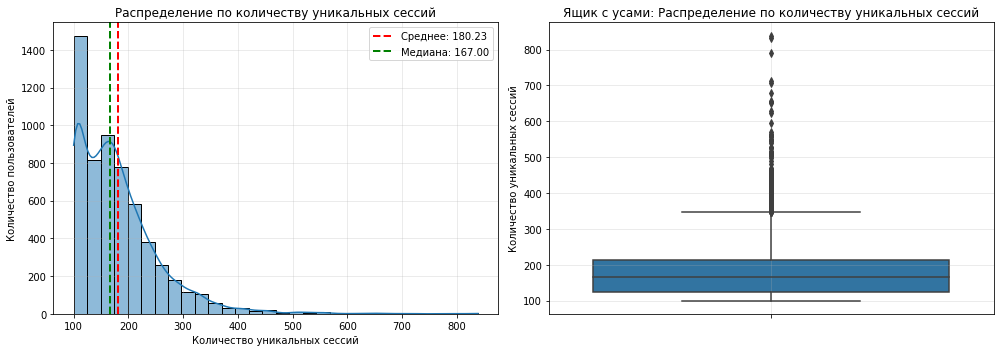

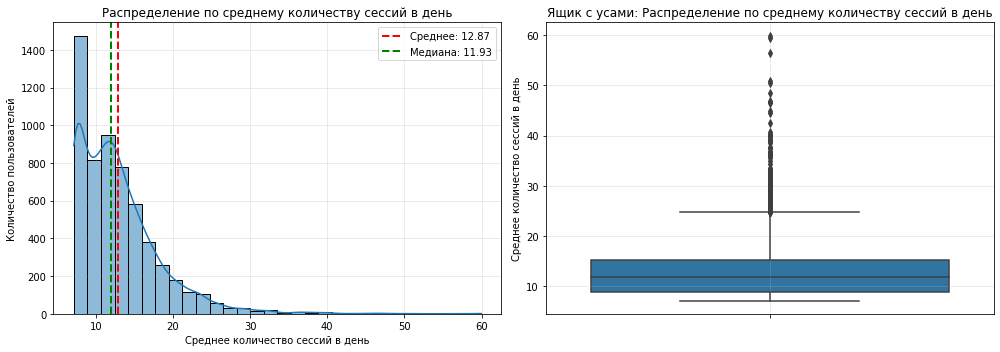

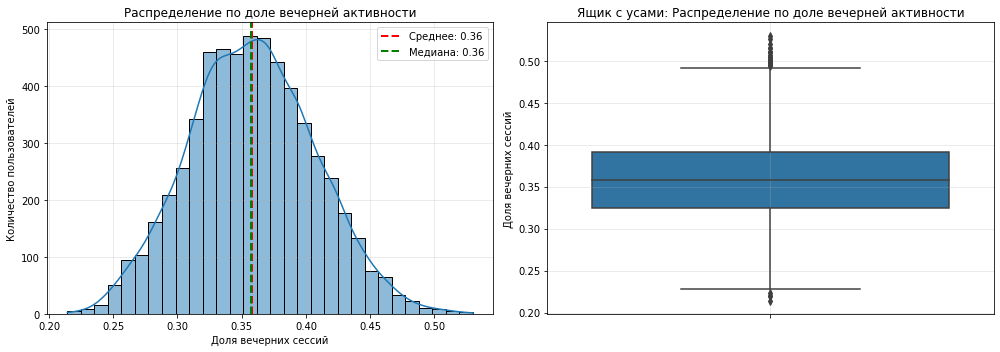

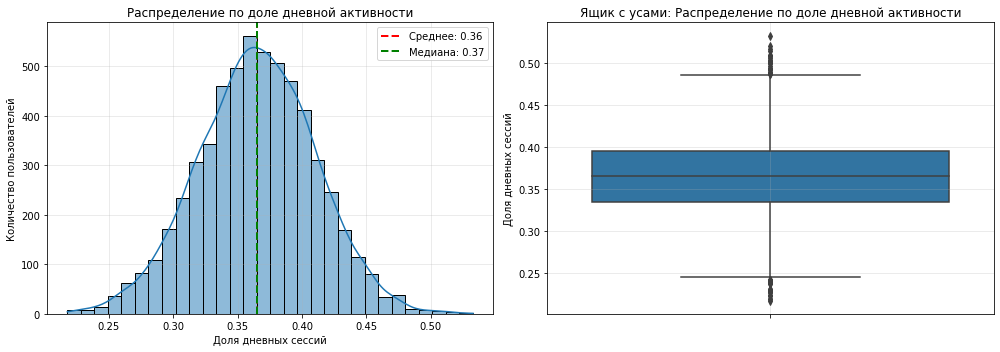

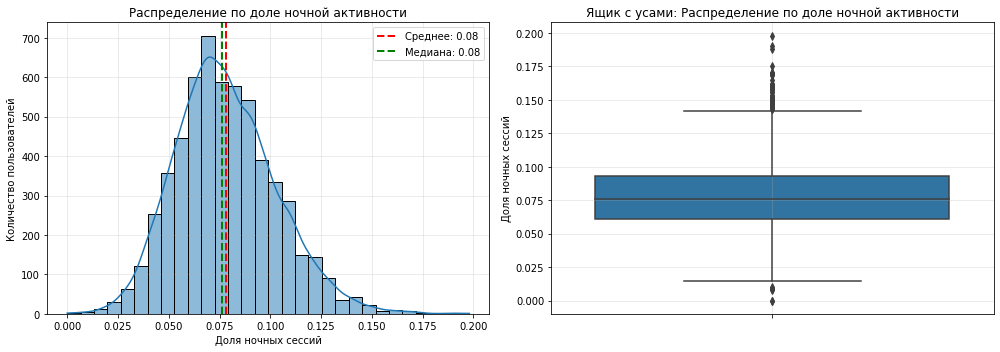

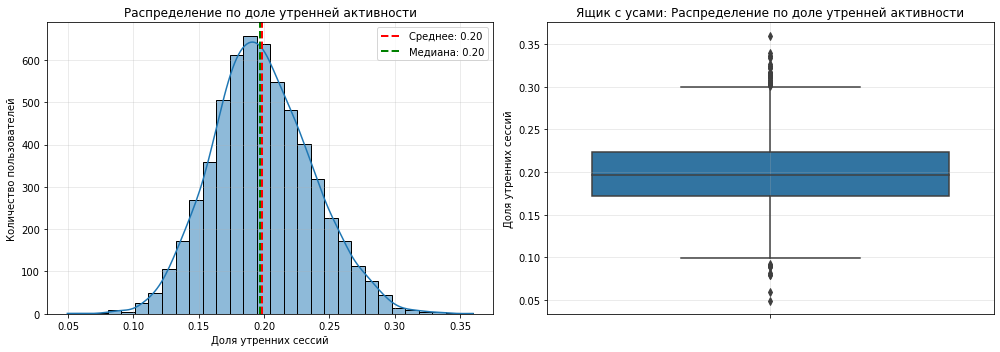

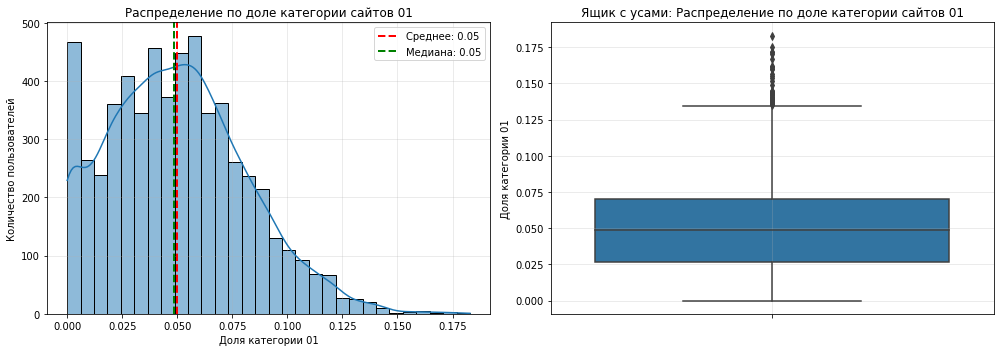

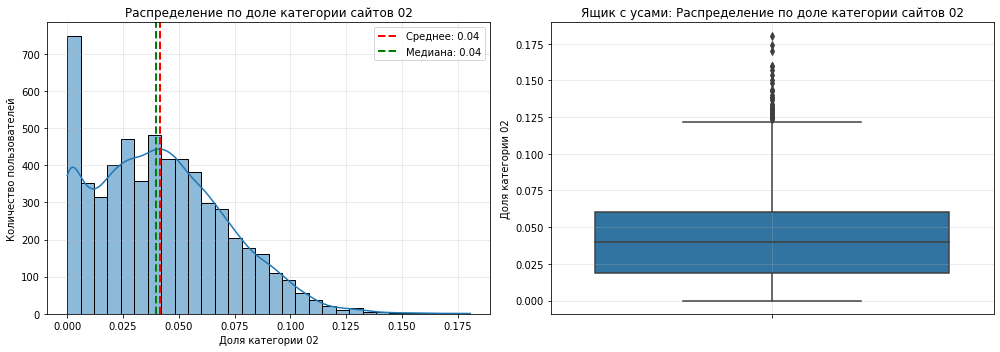

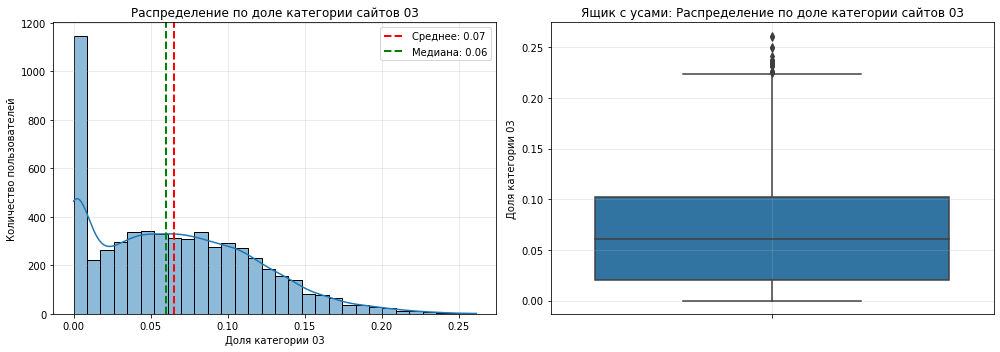

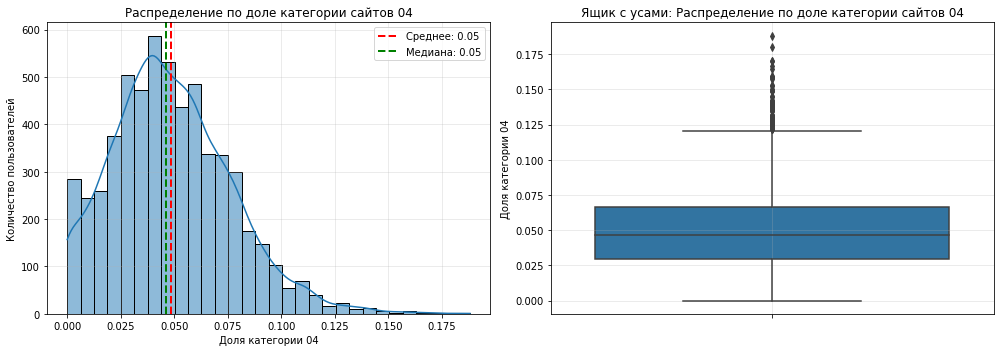

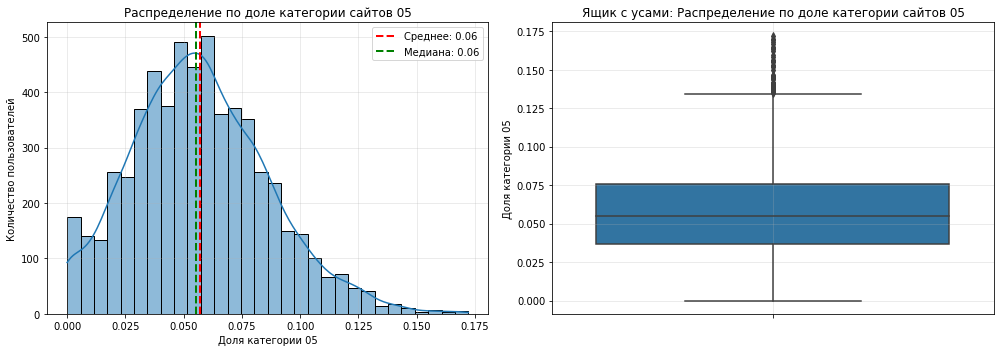

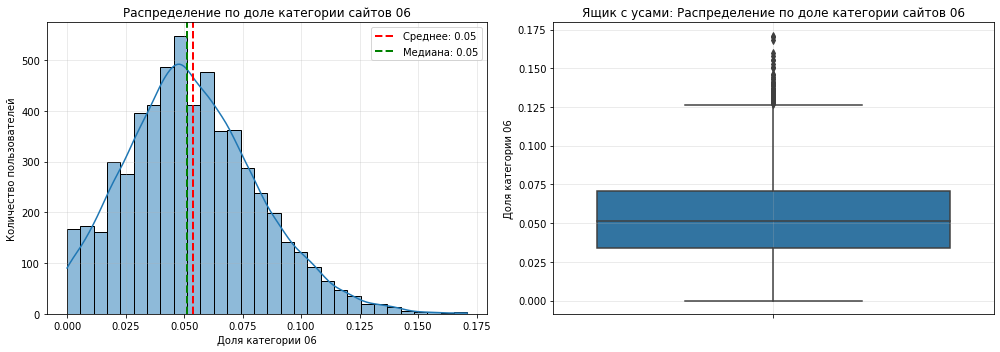

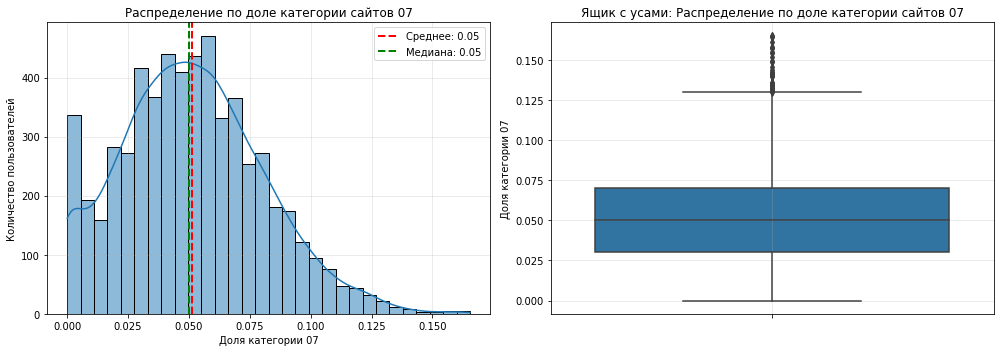

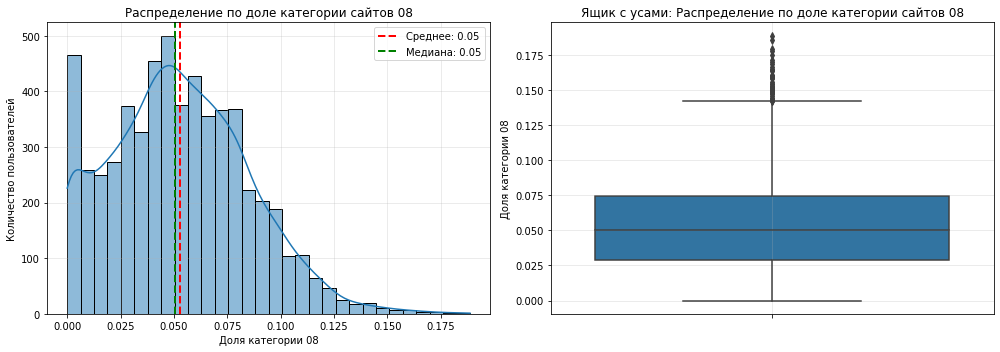

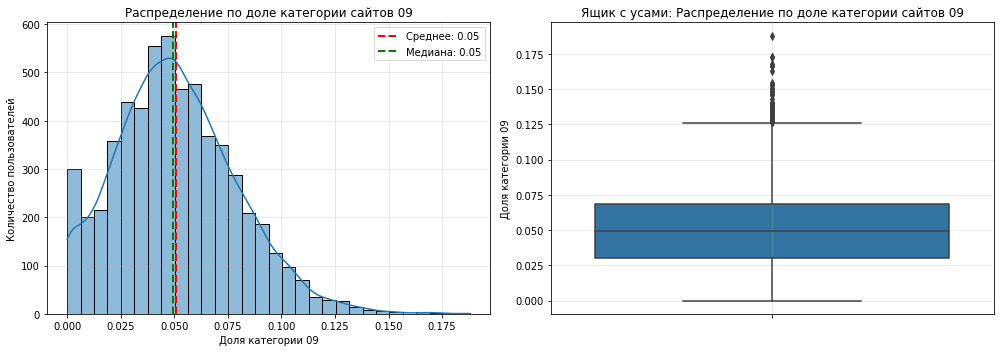

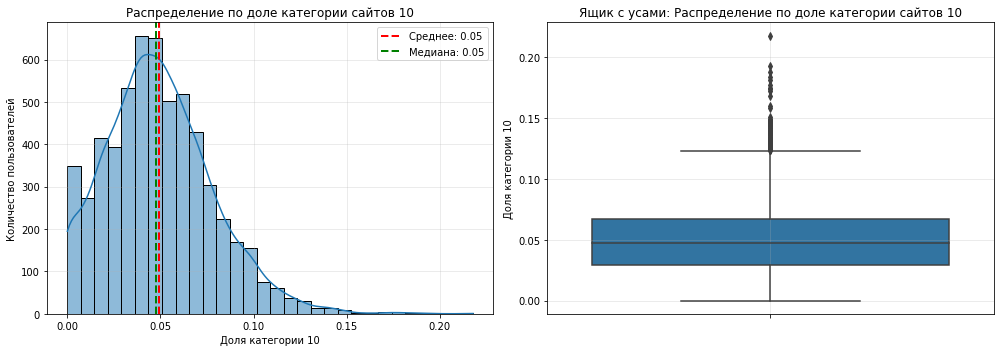

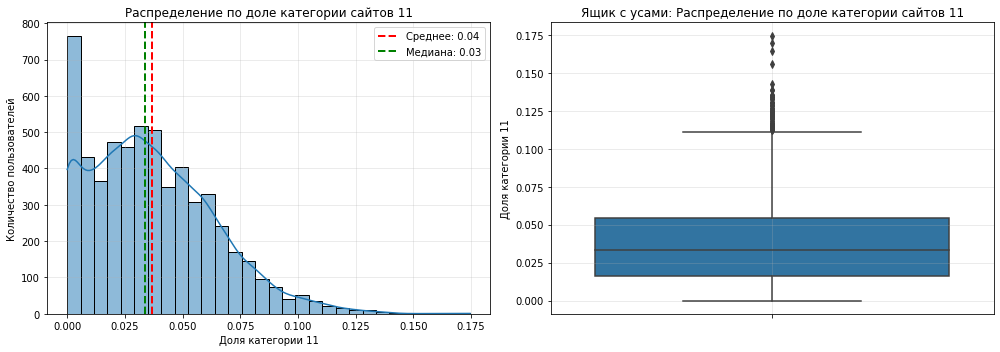

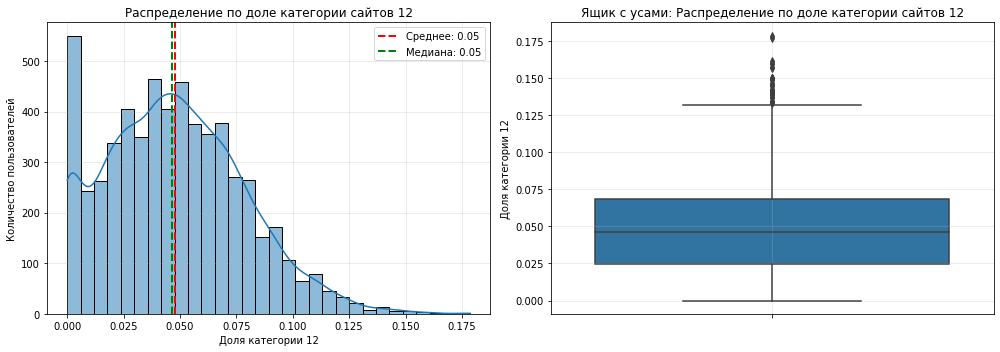

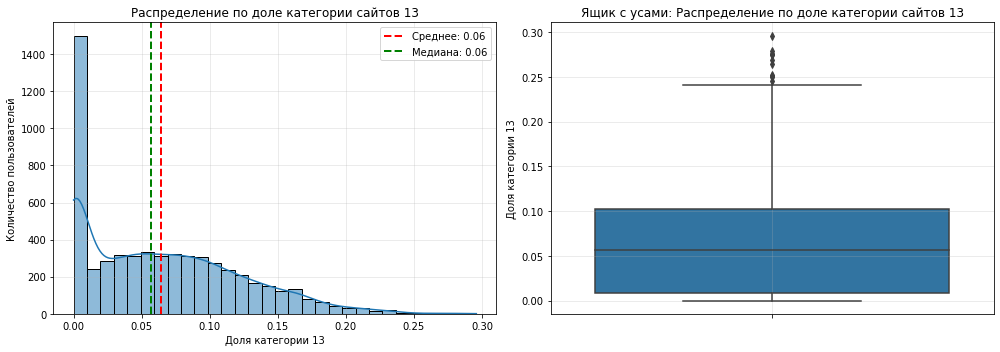

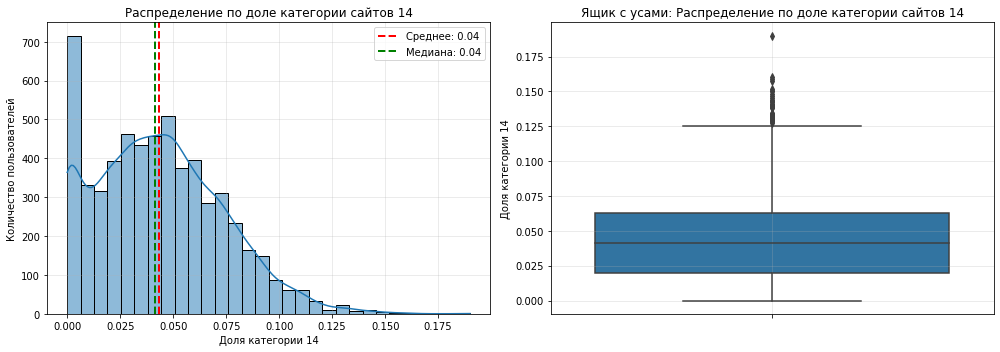

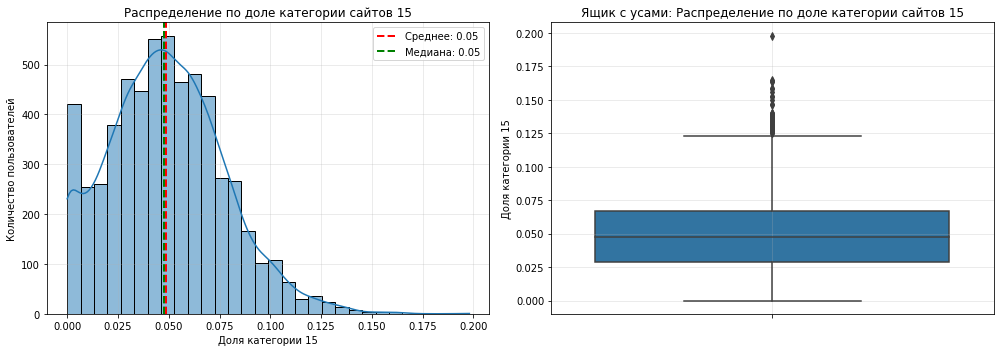

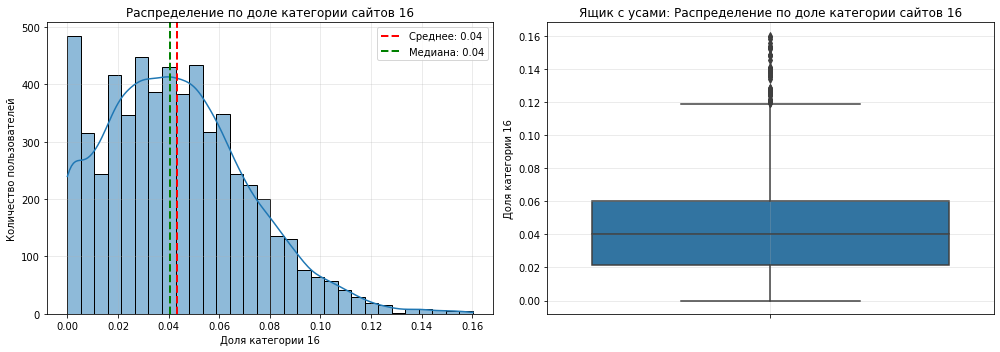

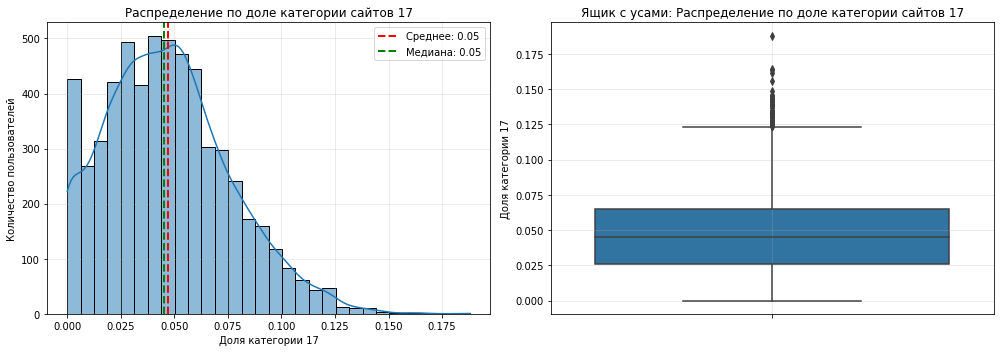

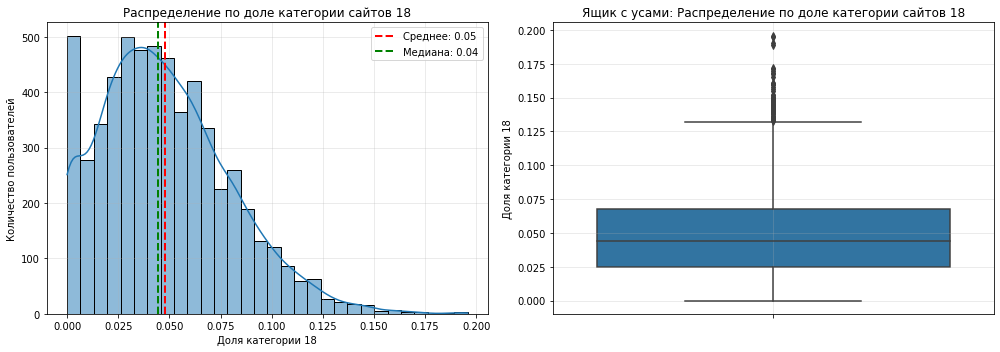

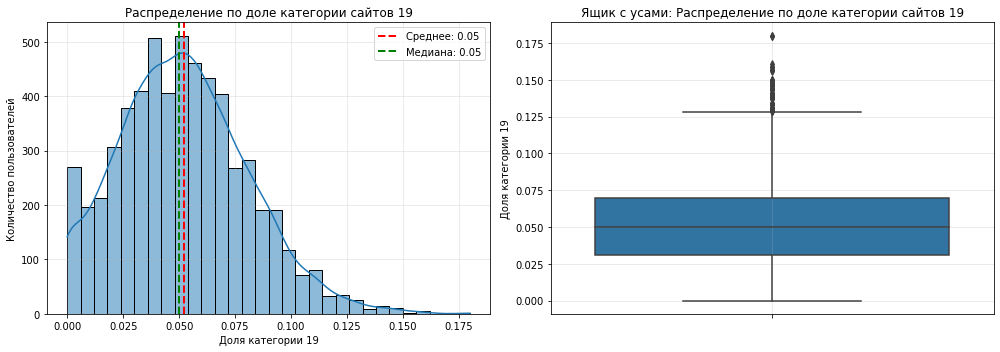

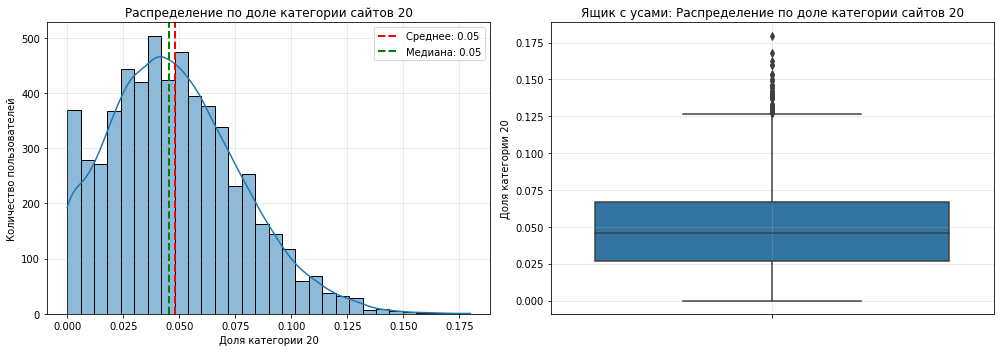

In [30]:
#Гистограммы и boxplot для непрерывных
for column in continuous_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    data = df[column].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    # Гистограмма
    sns.histplot(data, kde=True, bins=30, ax=ax1)
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                label=f'Медиана: {median_val:.2f}')
    
    # Подписи из словаря
    labels = plot_labels.get(column, {})
    ax1.set_title(labels.get('title', f'Гистограмма: {column}'))
    ax1.set_xlabel(labels.get('xlabel', column))
    ax1.set_ylabel(labels.get('ylabel', 'Количество наблюдений'))
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Boxplot
    sns.boxplot(y=data, ax=ax2)
    ax2.set_title(f'Ящик с усами: {labels.get("title", column)}')
    ax2.set_ylabel(labels.get('xlabel', column))
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Во всех столбцах присутствуют выбросы, но они нормальные и никаких преобразований с ними делать не требуется.

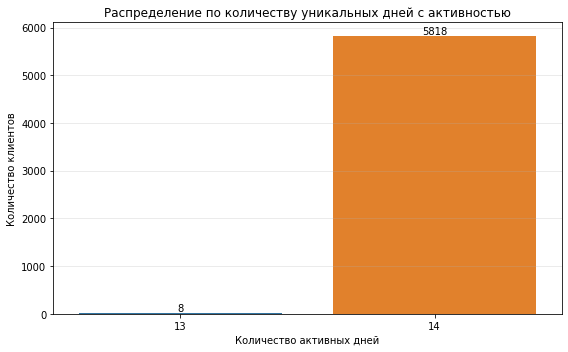

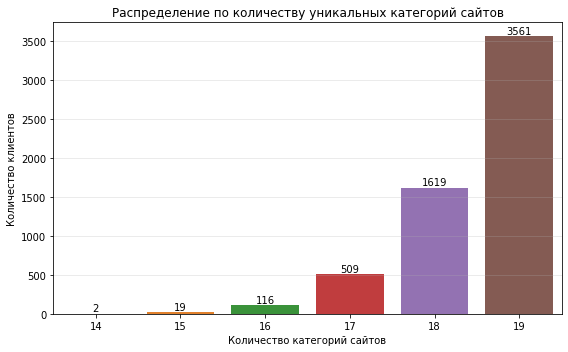

In [31]:
#Countplot для дискретных
for column in discrete_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    data = df[column].dropna().astype(int)
    labels = plot_labels.get(column, {})
    
    sns.countplot(x=data, ax=ax)
    ax.set_title(labels.get('title', f'Распределение: {column}'))
    ax.set_xlabel(labels.get('xlabel', column))
    ax.set_ylabel('Количество клиентов')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавим значения над столбцами
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

В столбце active_days_count почти все значения равны 14. Это значит, что пользователи каждый день, за которые предоставлены данные, заходили на сайты. Лишь 8 пользователей пропустили 1 день. В столбце website_category_count большинство значений равны 19. Лишь 2 значения равны 14.

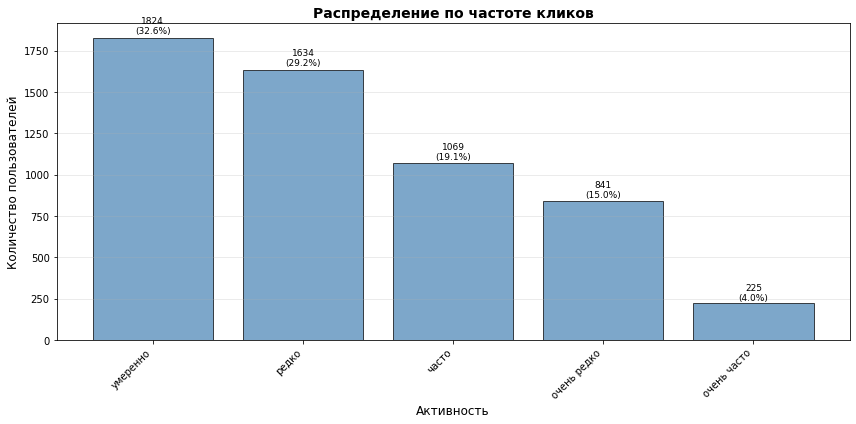

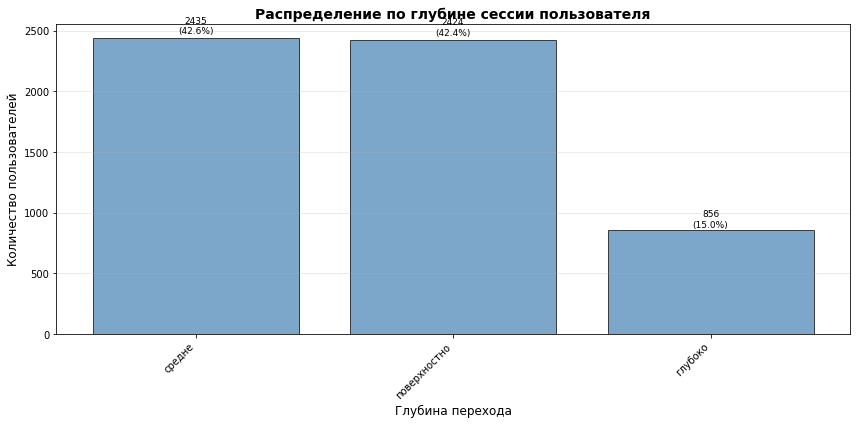

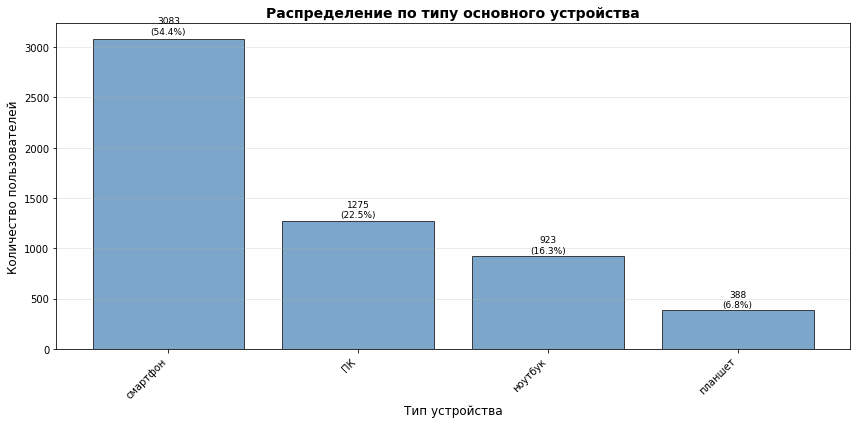

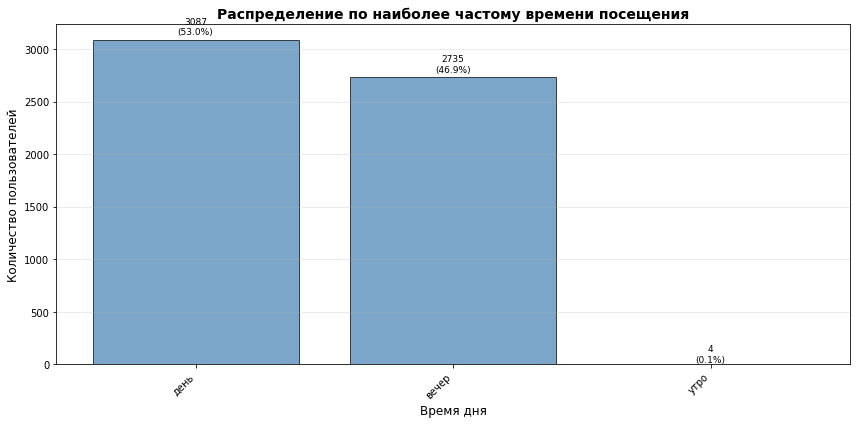

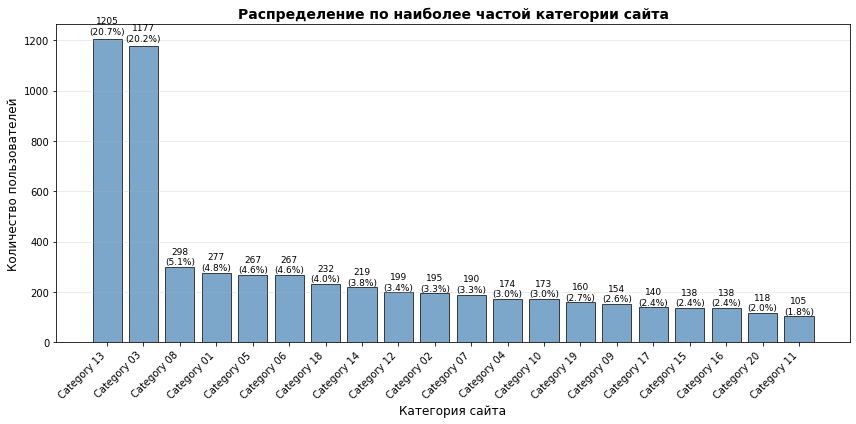

In [32]:
for column in categorical_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Считаем частоты
    value_counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100
    
    # Строим bar plot
    bars = ax.bar(range(len(value_counts)), value_counts.values, 
                  color='steelblue', alpha=0.7, edgecolor='black')
    
    # Добавляем значения и проценты на столбцы
    for i, (count, pct) in enumerate(zip(value_counts.values, percentages.values)):
        ax.text(i, count + (count * 0.01), f'{count}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=9)
        
    labels = plot_labels.get(column, {})
    ax.set_title(labels.get('title', f'Распределение: {column}'), fontsize=14, fontweight='bold')
    ax.set_xlabel(labels.get('xlabel', column), fontsize=12)
    ax.set_ylabel(labels.get('ylabel', 'Количество'), fontsize=12)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

Категориальные признаки распределены относительно равномерно. Лишь в в столбце с распределением по наиболее частому времени посещения сайта всего 0.1% пользователей посещает сайт утром, все остальные значения распределены между днем и вечером. В распределении по наиболее частой категории сайта сильно преобладают 2 категории над остальными.

**2.7 Корреляции**

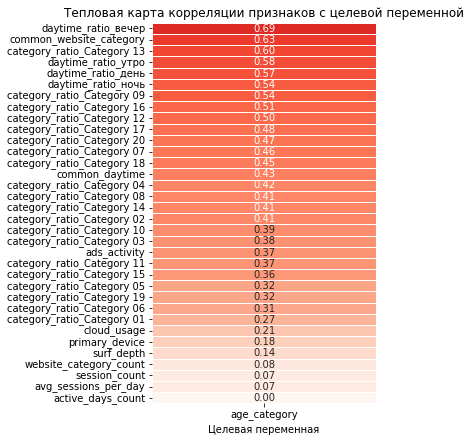

In [33]:
#Построим матрицу корреляции между признаками и целевой переменной
#Задаем интервальные столбцы
interval_cols = ['session_count', 'avg_sessions_per_day', 'daytime_ratio_вечер',
                'daytime_ratio_день', 'daytime_ratio_ночь', 'daytime_ratio_утро',
                'category_ratio_Category 01', 'category_ratio_Category 02',
                'category_ratio_Category 03', 'category_ratio_Category 04',
                'category_ratio_Category 05', 'category_ratio_Category 06',
                'category_ratio_Category 07', 'category_ratio_Category 08',
                'category_ratio_Category 09', 'category_ratio_Category 10',
                'category_ratio_Category 11', 'category_ratio_Category 12',
                'category_ratio_Category 13', 'category_ratio_Category 14',
                'category_ratio_Category 15', 'category_ratio_Category 16',
                'category_ratio_Category 17', 'category_ratio_Category 18',
                'category_ratio_Category 19', 'category_ratio_Category 20']
correlation_matrix = df[['session_count', 'avg_sessions_per_day', 'daytime_ratio_вечер', 
                         'daytime_ratio_день', 'daytime_ratio_ночь', 'daytime_ratio_утро', 
                         'category_ratio_Category 01', 'category_ratio_Category 02', 
                         'category_ratio_Category 03', 'category_ratio_Category 04', 
                         'category_ratio_Category 05', 'category_ratio_Category 06', 
                         'category_ratio_Category 07', 'category_ratio_Category 08',
                         'category_ratio_Category 09', 'category_ratio_Category 10',
                         'category_ratio_Category 11', 'category_ratio_Category 12',
                         'category_ratio_Category 13', 'category_ratio_Category 14',
                         'category_ratio_Category 15', 'category_ratio_Category 16',
                         'category_ratio_Category 17', 'category_ratio_Category 18',
                         'category_ratio_Category 19', 'category_ratio_Category 20', 
                         'website_category_count', 'ads_activity', 'surf_depth', 
                         'primary_device', 'cloud_usage', 'common_daytime', 'common_website_category', 
                         'active_days_count', 'age_category']].phik_matrix(interval_cols=interval_cols)
#Строим тепловую карту
plt.figure(figsize=(4, 7))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'age_category'][['age_category']].sort_values(by='age_category',
                                                                                                 ascending=False)

sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, linewidths=0.5, cbar=False)

plt.title('Тепловая карта корреляции признаков с целевой переменной')
plt.xlabel('Целевая переменная')
plt.show()

Самая большая связь у целевой переменной наблюдается с признаком 'daytime_ratio_вечер' (0.69). Наименьшая связь у целевой переменной с признаком 'active_days_count' - 0.00. Скорее всего это потому, что в признаке почти все значения одинаковые, и он не оказывает никакое влияние. Удалим этот признак.

In [34]:
df = df.drop(columns=['active_days_count'])

**2.8 Общие выводы по EDA**

Данные в целевой переменной распределены неравномерно. Больше всего пользователей находится в категории 56+ лет, а меньше всего - 18-25 лет. Так как данные несбалансированные, при выборе метрик будем ориентироваться на макро-усреднение. Для успешной работы модели нужно было избавиться от признаков, которые нужны лишь для записи данных и не несут пользы для модели. В данном датасете этот признак всего один - user_id, он был удален. Пропуски наблюдаются в столбцах ads_activity, surf_depth, primary_device, cloud_usage. Так как пропуски составляют меньше 5%, то категориальные столбцы заменим наиболее частым значением, а бинарный признак cloud_usage заменим модой. Все эти замены будем производить после деления на выборки. В категориальных признаках не наблюдается неявных дубликатов. Признаки ads_activity, surf_depth, primary_device, common_daytime, common_website_category имеют немного уникальных значений, поэтому их будем кодировать с помощью OneHotEncoder. Во всех непрерывных столбцах присутствуют выбросы, но они нормальные и никаких преобразований с ними делать не требуется. В столбце active_days_count почти все значения равны 14. Это значит, что пользователи каждый день, за которые предоставлены данные, заходили на сайты. Лишь 8 пользователей пропустили 1 день. В столбце website_category_count большинство значений равны 19. Лишь 2 значения равны 14. Категориальные признаки распределены относительно равномерно. Лишь в в столбце с распределением по наиболее частому времени посещения сайта всего 0.1% пользователей посещает сайт утром, все остальные значения распределены между днем и вечером. В распределении по наиболее частой категории сайта сильно преобладают 2 категории над остальными. Самая большая связь у целевой переменной наблюдается с признаком 'daytime_ratio_вечер' (0.69). Наименьшая связь у целевой переменной с признаком 'active_days_count' - 0.00. Скорее всего это потому, что в признаке почти все значения одинаковые, и он не оказывает никакое влияние. Признак 'active_days_count' был удален.

## Предобработка данных

In [35]:
#Поделим данные на выборки
X = df.drop(columns=['age_category'])
y = df['age_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                   stratify=y, shuffle=True,
                                                   random_state=RANDOM_STATE)

#Проверим доли классов
print(f'Распределение целевой переменной в обучающей выборке: {y_train.value_counts(normalize=True)}')
print(f'В тестовой:{y_test.value_counts(normalize=True)}')

Распределение целевой переменной в обучающей выборке: 4    0.303090
2    0.246935
3    0.215302
0    0.146395
1    0.088279
Name: age_category, dtype: float64
В тестовой:4    0.303204
2    0.247140
3    0.215103
0    0.146453
1    0.088101
Name: age_category, dtype: float64


In [36]:
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (4078, 33)
Размер тестовой выборки: (1748, 33)


In [37]:
#Числовые признаки
num_features = ['website_category_count', 'session_count', 'avg_sessions_per_day', 'daytime_ratio_вечер',
                'daytime_ratio_день', 'daytime_ratio_ночь', 'daytime_ratio_утро',
                'category_ratio_Category 01', 'category_ratio_Category 02',
                'category_ratio_Category 03', 'category_ratio_Category 04',
                'category_ratio_Category 05', 'category_ratio_Category 06',
                'category_ratio_Category 07', 'category_ratio_Category 08',
                'category_ratio_Category 09', 'category_ratio_Category 10',
                'category_ratio_Category 11', 'category_ratio_Category 12',
                'category_ratio_Category 13', 'category_ratio_Category 14',
                'category_ratio_Category 15', 'category_ratio_Category 16',
                'category_ratio_Category 17', 'category_ratio_Category 18',
                'category_ratio_Category 19', 'category_ratio_Category 20']

#Категориальные признаки
cat_features = ['common_website_category', 'common_daytime', 'ads_activity', 'primary_device', 'surf_depth']

#Бинарный признак
binary_features = ['cloud_usage']

In [38]:
#Пайплайн числовых данных
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

#Пайплайн для категориальных признаков
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

#Пайплайн для бинарного признака
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

In [39]:
#Объединяем в общий пайплайн
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat_one_hot', cat_pipeline, cat_features),
    ('binary', binary_pipeline, binary_features)
])

#Обучаем на train и преобразуем
X_train_processed = preprocessor.fit_transform(X_train)

## Обучение и оценка базовой модели

In [40]:
#Строим модель Dummy
dummy_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DummyClassifier(strategy='stratified'))
])

N_FOLDS = 5

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Определяем метрики с макро-усреднением
scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0)
}

# Запускаем кросс-валидацию
dummy_results = cross_validate(
    dummy_pipeline, 
    X_train, 
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Выводим результаты
print("Результаты кросс-валидации (макро-усреднение):")
for metric_name, scores in dummy_results.items():
    if metric_name.startswith('test_'):
        print(f"{metric_name}: {scores.mean():.3f}")

Результаты кросс-валидации (макро-усреднение):
test_f1_macro: 0.203
test_precision_macro: 0.204
test_recall_macro: 0.203


Базовая модель дает показатели 0.190 на f1 с макро-усреднением. Этот результат будет отправной точкой для других моделей.

In [41]:
#Строим LogisticRegression
lg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
#Запускаем кросс-валидацию
lg_results = cross_validate(lg_pipeline,
                       X_train, y_train, scoring=scoring,
                       cv=kfold, return_train_score=False,
                       n_jobs=-1, error_score='raise')

# Выводим результаты
print("Результаты кросс-валидации (макро-усреднение):")
for metric_name, scores in lg_results.items():
    if metric_name.startswith('test_'):
        print(f"{metric_name}: {scores.mean():.3f}")

Результаты кросс-валидации (макро-усреднение):
test_f1_macro: 0.827
test_precision_macro: 0.833
test_recall_macro: 0.824


Логистическая регрессия с базовыми гиперпараметрами показывает результаты почти в 4 раза лучше, чем базовая модель. Ее f1 с макро-усреднением равен 0.827.

In [42]:
#Построим модель SVC
svc_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(random_state=RANDOM_STATE))
])

#Запускаем кросс-валидацию
svc_results = cross_validate(svc_pipeline,
                       X_train, y_train, scoring=scoring,
                       cv=kfold, return_train_score=False,
                       n_jobs=-1, error_score='raise')

# Выводим результаты
print("Результаты кросс-валидации (макро-усреднение):")
for metric_name, scores in svc_results.items():
    if metric_name.startswith('test_'):
        print(f"{metric_name}: {scores.mean():.3f}")

Результаты кросс-валидации (макро-усреднение):
test_f1_macro: 0.889
test_precision_macro: 0.894
test_recall_macro: 0.887


Модель SVC с базовыми гиперпараметрами показывает примерно те же метрики, что и логистическая регрессия. Однако, ее f1 немного выше(0.889).

## Создание и отбор признаков

In [43]:
#Получаем имена признаков
ohe_features = (
    preprocessor
    .named_transformers_['cat_one_hot']
    .named_steps['encoder']
    .get_feature_names_out(cat_features)
)

#Собираем имена в правильном порядке
feature_names = (num_features +
                list(ohe_features) +
                binary_features)

#Преобразуем в датафрейм
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

y_train_series = pd.Series(y_train).reset_index(drop=True)

In [44]:
#Функция для создания новых признаков
def create_enhanced_features(X):
    X_enhanced = X.copy()
    
    #Куб и квадрат для session_count
    X_enhanced['cubed_sessions'] = X['session_count'] ** 3
    X_enhanced['squared_sessions'] = X['session_count'] ** 2
    
    #Возведем avg_sessions_per_day в квадрат
    X_enhanced['avg_sessions_squared'] = X['avg_sessions_per_day'] ** 2
    
    #Попробуем умножить daytime_ratio_вечер и category_ratio_Category 13, так как у них наибольшая связь
    #с целевой переменной
    X_enhanced['evening_category_13_multiplied'] = X['daytime_ratio_вечер'] * X['category_ratio_Category 13']
    
    #Возведем website_category_count в квадрат
    X_enhanced['category_count_squared'] = X['website_category_count'] ** 2
    
    #Поделим daytime_ratio_ночь на category_ratio_Category 01
    X_enhanced['night_category_1'] = X['daytime_ratio_ночь']/(X['category_ratio_Category 01'] + 1)
    
    return X_enhanced

In [45]:
#Применяем функцию
X_train_enhanced = create_enhanced_features(X_train_df)

print(f'Всего признаков после генерации: {X_train_enhanced.shape[1]}')

Всего признаков после генерации: 64


**5.1 Фильтрационные методы**

In [46]:
vs_quasi = VarianceThreshold(threshold=0.05) 
vs_quasi.fit(X_train_enhanced)

features_after_var = X_train_enhanced.columns[vs_quasi.get_support()].tolist()
X_train_final = X_train_enhanced[features_after_var]

print(f'Признаков после VarianceThreshold: {len(features_after_var)}\n') 

Признаков после VarianceThreshold: 45



Так как признаки уже стандартизированы и закодированы, то для порога VarianceThreshold было выбрано достаточно низкое значение - 0.05. После этого этапа осталось 45 признака.

In [47]:
#Считаем корреляцию с целевой переменной
correlation = X_train_final.corrwith(y_train_series).abs().sort_values(ascending=False)

print('Топ-15 признаков по корреляции с целевой переменной:')
print(correlation.head(15))

Топ-15 признаков по корреляции с целевой переменной:
daytime_ratio_вечер                    0.597661
common_daytime_день                    0.496995
daytime_ratio_день                     0.496181
daytime_ratio_утро                     0.495858
daytime_ratio_ночь                     0.478944
category_ratio_Category 09             0.436002
category_ratio_Category 13             0.427125
category_ratio_Category 17             0.335349
common_website_category_Category 13    0.328686
category_ratio_Category 12             0.328545
category_ratio_Category 14             0.304713
category_ratio_Category 19             0.258216
category_ratio_Category 20             0.249553
primary_device_смартфон                0.202853
category_ratio_Category 02             0.198151
dtype: float64


In [48]:
CORR_THRESHOLD = 0.01

top_corr_features = correlation[correlation > CORR_THRESHOLD].index.tolist()

print(f'Отобрано {len(top_corr_features)} признаков после фильтрации')

Отобрано 38 признаков после фильтрации


Для хорошей работы модели отберем признаки не по количеству, а по их корреляции с целевой переменной. Для таких данных подойдет порог - 0.01. После фильтрационного этапа в данных осталось 42 признаков.

**5.2  Метод - обёртка**

In [49]:
rfe_selector = RFE(estimator=LogisticRegression(random_state=RANDOM_STATE, 
                                                class_weight = 'balanced', 
                                                max_iter=5000, n_jobs=-1), n_features_to_select=30)
rfe_selector.fit(X_train_final, y_train_series)

rfe_features = X_train_final.columns[rfe_selector.support_].tolist()

#Смотрим ранг
rfe_ranking = pd.DataFrame({
    'Признак': X_train_final.columns,
    'Ранг': rfe_selector.ranking_
}).sort_values(by='Ранг')

print(rfe_ranking)

                                Признак  Ранг
22           category_ratio_Category 16     1
34               primary_device_планшет     1
32                   ads_activity_часто     1
31                ads_activity_умеренно     1
28  common_website_category_Category 13     1
27  common_website_category_Category 03     1
26           category_ratio_Category 20     1
25           category_ratio_Category 19     1
24           category_ratio_Category 18     1
23           category_ratio_Category 17     1
21           category_ratio_Category 15     1
20           category_ratio_Category 14     1
19           category_ratio_Category 13     1
35              primary_device_смартфон     1
17           category_ratio_Category 11     1
16           category_ratio_Category 10     1
18           category_ratio_Category 12     1
14           category_ratio_Category 08     1
38                          cloud_usage     1
3                   daytime_ratio_вечер     1
4                    daytime_ratio

Здесь мы можем видеть, какие признаки отобрал метод-обёртки. Далее объединим их с признаками из фильтрационного метода.

**5.3 Финальный набор признаков**

In [50]:
#Находим пересечение
final_features = list(set(top_corr_features).intersection(set(rfe_features)))
print(f'Итоговое количество признаков: {len(final_features)}')
print('Финальный набор признаков:')
for feat in final_features:
    print(f' - {feat}')
    
X_train_finish = X_train_df[final_features]

Итоговое количество признаков: 28
Финальный набор признаков:
 - ads_activity_умеренно
 - daytime_ratio_ночь
 - category_ratio_Category 03
 - category_ratio_Category 20
 - category_ratio_Category 13
 - category_ratio_Category 18
 - category_ratio_Category 11
 - category_ratio_Category 19
 - category_ratio_Category 12
 - category_ratio_Category 08
 - category_ratio_Category 04
 - category_ratio_Category 16
 - primary_device_смартфон
 - category_ratio_Category 09
 - category_ratio_Category 02
 - category_ratio_Category 15
 - category_ratio_Category 17
 - cloud_usage
 - daytime_ratio_вечер
 - category_ratio_Category 14
 - common_website_category_Category 13
 - category_ratio_Category 07
 - ads_activity_часто
 - category_ratio_Category 06
 - daytime_ratio_утро
 - daytime_ratio_день
 - primary_device_планшет
 - category_ratio_Category 10


## Подбор гиперпараметров моделей

**6.1 GridSearchCV**

In [51]:
#Обновляем пайплайны, чтобы в них был rfe
lg_pipeline_new = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', rfe_selector),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=5000))
])

svc_pipeline_new = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', rfe_selector),
    ('model', SVC(probability=True, random_state=RANDOM_STATE))
])

In [52]:
#Задаем параметрическую сетку
#Задаем параметрическую сетку
param_grid_svc = {
    'model__kernel': ['rbf', 'linear', 'poly'],
    'model__C': [0.1, 1],
    'model__gamma': ['scale'],
    'model__class_weight': ['balanced'],
    'model__decision_function_shape': ['ovo', 'ovr']
}
    
param_grid_lg = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'saga', 'newton-cg'],
    'model__multi_class': ['multinomial'],
    'model__class_weight': ['balanced']
}

In [53]:
#Grid для Logistic Regression
grid_lg = GridSearchCV(estimator=lg_pipeline_new,
                      param_grid = param_grid_lg,
                      cv=kfold,
                      scoring=scoring,
                       refit='f1_macro',
                      n_jobs=-1,
                      verbose=1)
grid_lg.fit(X_train, y_train)

best_params_lg = grid_lg.best_params_

best_estimator_lg = grid_lg.best_estimator_

best_score_lg = round(grid_lg.best_score_, 3)

print("Лучшие гиперпараметры:", best_params_lg)
print("Лучшая модель:", best_estimator_lg)
print("Лучший средний результат F1-макро на кросс-валидации:", best_score_lg)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Лучшие гиперпараметры: {'model__C': 10, 'model__class_weight': 'balanced', 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Лучшая модель: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['website_category_count',
                                                   'session_count',
                                                   'avg_sessions_per_day',
                                                   'daytime_ratio_вечер',
                                   

Лучшей моделью логистической регрессии после GridSearchCV стала C=10, class_weight='balanced', multi_class='multinomial', penalty=L2, solver='lbfgs'. Ее F1 с макро-усреднением = 0.809.

In [54]:
#Grid для SVC
grid_svc = GridSearchCV(estimator=svc_pipeline_new,
                      param_grid = param_grid_svc,
                      cv=kfold,
                      scoring=scoring,
                        refit='f1_macro',
                      n_jobs=-1,
                      verbose=1)
grid_svc.fit(X_train, y_train)

best_params_svc = grid_svc.best_params_

best_estimator_svc = grid_svc.best_estimator_

best_score_svc = round(grid_svc.best_score_, 3)

print("Лучшие гиперпараметры:", best_params_svc)
print("Лучшая модель:", best_estimator_svc)
print("Лучший средний результат F1-макро на кросс-валидации:", best_score_svc)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие гиперпараметры: {'model__C': 1, 'model__class_weight': 'balanced', 'model__decision_function_shape': 'ovo', 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Лучшая модель: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['website_category_count',
                                                   'session_count',
                                                   'avg_sessions_per_day',
                                                   'daytime_ratio_вечер',
                                

Лучшая SVC модель оказалась с гиперпараметрами C=1, class_weight='balanced', shape=OneVsOne, gamma=scale, kernel=rbf. Ее F1 с макро-усреднением = 0.873. Посмотрим метрики всех моделей в одной таблице.

In [55]:
results_table = pd.DataFrame([
    {'Модель': 'DummyClassifier', 'F1-macro (CV)': 0.190},
    {'Модель': 'LogisticRegression', 'F1-macro (CV)': best_score_lg},
    {'Модель': 'SVC', 'F1-macro (CV)': best_score_svc},
]).sort_values('F1-macro (CV)', ascending=False)
display(results_table)

,Модель,F1-macro (CV)
2,SVC,0.873
1,LogisticRegression,0.809
0,DummyClassifier,0.190


Модель SVC показывает лучшие результат по F1 с макро-усреднением, поэтому для дальнейшего анализа на тестовой выборке берем именно ее.

**6.2 Тестируем финальную модель**

In [56]:
#Обучаем финальную модель на всей выборке
best_estimator_svc.fit(X_train, y_train)

y_pred_test = best_estimator_svc.predict(X_test)
y_pred_proba_test = best_estimator_svc.predict_proba(X_test)

test_f1 = f1_score(y_test, y_pred_test, average='macro')
test_precision = precision_score(y_test, y_pred_test, average='macro')
test_recall = recall_score(y_test, y_pred_test, average='macro')

print("Оценка на тестовых данных:")
print(f"F1-score: {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

print(classification_report(y_test, y_pred_test))

Оценка на тестовых данных:
F1-score: 0.8533
Precision: 0.8486
Recall: 0.8620
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       256
           1       0.68      0.84      0.75       154
           2       0.86      0.85      0.85       432
           3       0.92      0.86      0.89       376
           4       0.92      0.92      0.92       530

    accuracy                           0.87      1748
   macro avg       0.85      0.86      0.85      1748
weighted avg       0.88      0.87      0.87      1748



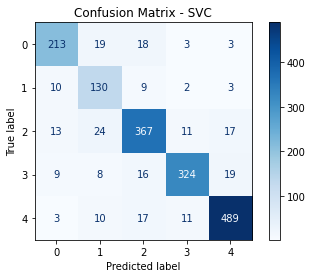

In [57]:
#Построим матрицу ошибок
unique_classes = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred_test)

# Визуализируем
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVC')
plt.show()

На тестовых данных модель показывает такие же хорошие результаты, как и на обучающих. Это говорит о ее стабильности. Лучше всего модель опознает последний класс, так как по нему есть больше всего данных. Хуже всего она опознает класс с меньшим количеством данных, однако все равно сохраняет хорошее качество. F1 с макро-усреднением на тестовых данных равно 0.8533, что соответствует изначальным требованиям задания(>0.75). Однако перед сохранением модели проверим ее калибровку.

**6.3 Калибровка модели**

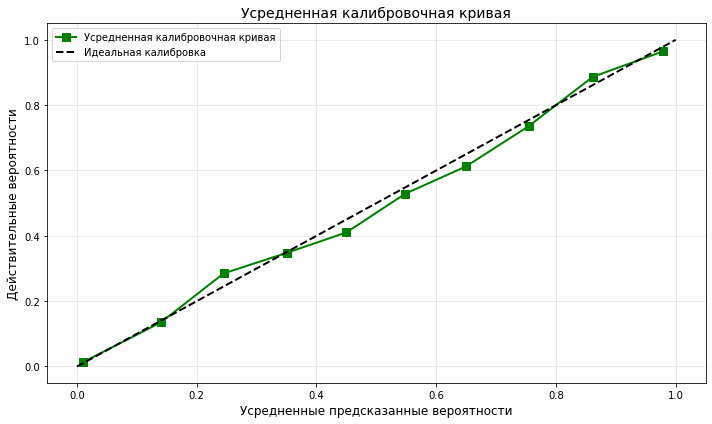

In [58]:
# Получаем вероятности
y_pred_proba_test = best_estimator_svc.predict_proba(X_test)
unique_classes = np.unique(y_train)

# Собираем все предсказания для всех классов
all_proba = []
all_true = []

for i, class_name in enumerate(unique_classes):
    y_test_binary = (y_test == class_name).astype(int)
    y_proba_class = y_pred_proba_test[:, i]
    
    all_proba.extend(y_proba_class)
    all_true.extend(y_test_binary)

# Строим общую калибровочную кривую
prob_true, prob_pred = calibration_curve(all_true, all_proba, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, 
         marker='s', linewidth=2, markersize=8,
         label='Усредненная калибровочная кривая', color='green')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')

plt.xlabel('Усредненные предсказанные вероятности', fontsize=12)
plt.ylabel('Действительные вероятности', fontsize=12)
plt.title(f'Усредненная калибровочная кривая', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По калибровочной кривой можно понять, что модель откалибрована хорошо. Ее вероятности часто совпадают с реальными вероятностями, а если еще учесть ее метрики на тестовой выборке, то ее точно можно рекомендовать к использованию в продакшене.

## Подготовка артефактов модели для внедрения

In [59]:
# Создаем полный артефакт для продакшена
date = datetime.now().strftime("%Y%m%d")
version = "1.0"

full_model_name = f"production_model_artifact_v{version}_{date}.pkl"

full_artifact = {
    'func_build_matrix': build_feature_matrix,
    'func_enhance_features': create_enhanced_features,
    'pipeline': best_estimator_svc,
    'preprocessor': preprocessor,
    'final_features': final_features,
    'num_features': num_features,
    'cat_features': cat_features,
    'binary_features': binary_features,
    
    'metadata': {
        'model_version': version,
        'training_date': datetime.now().strftime("%d.%m.%Y"),
        'model_type': 'SVC',
        'hyperparameters': best_estimator_svc.named_steps['model'].get_params(),
        'performance': {
            'f1_macro_test': float(test_f1),
            'precision_macro_test': float(test_precision),
            'recall_macro_test': float(test_recall)
        },
        'feature_count': len(final_features)
    }
}

# Сохраняем артефакт
joblib.dump(full_artifact, full_model_name)
print(f"Модель сохранена в {full_model_name}")

Модель сохранена в production_model_artifact_v1.0_20260423.pkl


In [60]:
#Загружаем артифакт
artifact = joblib.load(full_model_name)

loaded_pipeline = artifact['pipeline']
loaded_build_func = artifact['func_build_matrix']

df_raw = loaded_build_func(users, visits, ads_activity, surf_depth, primary_device, cloud_usage)

X_input = df_raw[X_train.columns]

predictions = loaded_pipeline.predict(X_input)

print(f'Первые 5 предсказаний: {predictions[:5]}')

original_preds = best_estimator_svc.predict(X_test)
loaded_preds = loaded_pipeline.predict(X_test[X_train.columns])
assert (original_preds == loaded_preds).all(), 'Предсказания не совпадают!'
print('Проверка пройдена: предсказания совпадают')

Первые 5 предсказаний: [4 2 0 4 0]
Проверка пройдена: предсказания совпадают


## Выводы о результатах работы

Во время работы над проектом был проведен полноценный анализ данных. Сначала все датасеты были загружены и объединены с помощью функции. После был проведен первичный анализ данных и были выявлены первые паттерны пользователей. Далее была изучена целевая переменная, что выявило несбалансированность значений в ней. После этого были найдены дубликаты и удалены вместе со столбцом user_id, который не пригодился бы для обучения модели. Далее признаки были исследованы на наличие неявных дубликатов, выбросов или других аномалий, а также была создана тепловая карта корреляции целевой переменной с признаками. Наибольшую связь имеет признак daytime_ratio_вечер, который показывает связь 0,69. По итогам исследовательского анализа данных были удалены столцы user_id и active_days_count, который был квази-константным и не имел никакой связи с переменной.

После анализа была проведена предобработка данных. Для начала данные были разделены на обучающую и тестовую выборки  в пропорциях 70/30. Для разных типов данных были созданы пайплайны, которые затем были объединены в один общий. 

Далее была создана функция, создающая новые признаки в данных. Чтобы найти нелинейные связи, некоторые признаки были возведены в квадрат и куб, а также умножены или поделены друг на друга. Дальнейшая работа включала в себя отбор признаков. Были удалены квази-константные признаки и признаки, имеющие слабую связь с переменной. После фильтрационного метода был проведен метод-обёртки. Общие признаки этих двух методов и составили окончательный набор. Всего было выбрано 29 признаков.

Далее пайплайны были обновлены, чтобы включать в себя отбор признаков. К этим пайплайнам был применен GridSearchCV, выявивший лучшую модель по макро-усредненному F1. Этой моделью оказалась SVC с C=1, class_weight=balanced, decision_function_shape=ovo, gamma=scale, kernel = rbf. Эта модель показала 0.853 по F1 на кросс-валидации и 0.8254 на тестовой выборке. Всё это говорит о её стабильности и хороших результатах. Для уверенности в работе модели была построена калибровочная кривая, выявившая, что предсказанные моделью вероятности близки к действительным вероятностям. Это всё говорит о том, что модель готова к внедрению в продакшен и имеет очень хорошие показатели.

**Рекомендации для дальнейшей работы:** на данный момент модель хуже всего предсказывает класс 1 - 18-25 лет. Это происходит из-за того, что данных этого класса меньше всего в датасете. Для улучшения работы модели и верного предсказывания класса, можно собрать больше данных всех классов, уравнять их и дообучить модель. Также, можно добавить признаки на основе временных паттернов внутри суток или же поискать другое взаимодействие между признаками.

**Рекомендации бизнесу:** на данный момент в данных присутствует класс 4 - 56+ лет. Однако, такая выборка слишком большая. Большинство людей после 80-85 лет намного реже пользуются мобильными устройствами и еще реже доверяют рекламе в интернете, боясь быть обманутыми. Возможно, стоит разделить данные, чтобы исключить трату ресурсов на класс, который вряд ли будет заинтересован предложением.